In [2]:
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.distributions.constraints import real
import pandas as pd

import pollux as plx
from pollux.models.transforms import LinearTransform

from process_rvs import process_spectra

jax.config.update("jax_enable_x64", True)

from matplotlib import rcParams

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)


# 1. Data

In [3]:
df_stars = pd.read_pickle('data/training_set_dwarfs.pkl')
df_gaia_rvs = pd.read_pickle('data/test_set_KDTree_dwarfs_rvs_fluxes.pkl')

In [4]:
n_all_stars = len(df_stars)
#n_stars = 500  # number of simulated stars to generate in the train and test sets
n_stars = n_all_stars
labels = ['teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 'ni_h', 'ca_h', 'm_h_atm', 'alpha_m_atm']
n_labels = len(labels)  # number of labels to generate per star
#n_latents = n_labels * 4  # size of the latent vector per star
n_latents = 21
n_flux = 2401  # number of spectral flux pixels per star

rng = np.random.default_rng(seed=8675309)

A = np.zeros((n_labels, n_latents))
A[0, 0] = 1.0
A[1, 1] = 1.0

B = rng.normal(scale=0.1, size=(n_flux, n_latents))
B[:, 0] = B[:, 0] + 4 * np.exp(-0.5 * (np.arange(n_flux) - n_flux / 2) ** 2 / 5**2)
B[:, 1] = B[:, 1] + 2 * np.exp(-0.5 * (np.arange(n_flux) - n_flux / 4) ** 2 / 3**2)

In [5]:
df_stars = df_stars[:n_stars]
df_gaia_rvs = df_gaia_rvs[:500]
print("len test set stars = ", len(df_stars))
print("len all stars = ", len(df_gaia_rvs))

len test set stars =  2392
len all stars =  500


In [6]:
df_stars

,source_id,ra_x,dec_x,parallax,pmra_x,pmdec,radial_velocity,rvs_spec_sig_to_noise,teff_gspphot,logg_gspphot,...,raw_e_ti_h,raw_v_h,raw_e_v_h,source_pk,v_astra,t_elapsed,t_overhead,tag,flux,flux_error
9,466148713494744960,44.711583,60.952875,7.839938,134.742412,-60.590321,21.737780,336.00598,5619.7100,3.9824,...,0.002828,0.756,0.001,176023,7000,NaN,0.0,,"[0.9876227, 0.9849612, 0.9867141, 0.99096936, ...","[0.0031395045, 0.0030226242, 0.0030263097, 0.0..."
18,576766798790504960,134.098553,0.933118,3.753271,-37.391015,-14.404915,71.010350,153.52151,4973.4814,3.5589,...,0.002236,-0.031,0.001,279920,7000,NaN,0.0,,"[0.9675072, 0.9593079, 0.95340496, 0.9592599, ...","[0.0063810726, 0.006188199, 0.0064556883, 0.00..."
22,577619637559771776,133.588315,1.651067,11.988297,-55.848622,17.169366,36.638268,230.85031,6164.1420,4.3465,...,0.003162,-0.401,0.002,26110,7000,NaN,0.0,,"[0.980817, 0.9812472, 0.9843495, 0.99303967, 0...","[0.009111124, 0.00867185, 0.00848364, 0.006929..."
49,598905667277186304,132.458236,11.590415,2.297977,-13.055830,-15.076411,39.435300,105.26275,6187.8790,3.7988,...,0.003606,0.372,0.002,78188,7000,NaN,0.0,,"[1.0066339, 0.9978674, 1.0073221, 1.008373, 0....","[0.011028829, 0.009875615, 0.009465829, 0.0094..."
57,605125089159188352,133.063269,12.654781,3.140980,-9.780171,-1.627817,-6.434080,103.62879,6059.9497,3.9902,...,0.004472,0.377,0.001,78171,7000,NaN,0.0,,"[0.9973197, 0.99177766, 0.987028, 0.9858101, 0...","[0.015805105, 0.013609516, 0.01596615, 0.01990..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10196,6914333056578041472,311.696762,-4.930617,6.272869,-17.723084,-47.082525,-57.296463,142.08140,5652.8364,4.1782,...,0.003606,-0.151,0.002,173744,7000,NaN,0.0,,"[--, --, --, --, --, --, --, --, --, 0.9662146...","[--, --, --, --, --, --, --, --, --, 0.0161556..."
10200,6914596909304918400,310.446090,-4.493748,5.677463,-37.623223,-31.805483,57.801870,208.96510,5915.7830,4.2815,...,0.004472,0.119,0.001,166429,7000,NaN,0.0,,"[0.99470663, 0.9912103, 0.99242735, 0.9937861,...","[0.004718569, 0.004758919, 0.0046248366, 0.004..."
10201,6914655316563957248,310.695155,-4.204464,6.438165,16.460890,-27.577347,-17.133873,150.96835,5869.4077,4.1885,...,0.005657,0.013,0.002,159593,7000,NaN,0.0,,"[0.9977205, 0.9992672, 1.0025542, 1.0042057, 1...","[0.012067795, 0.009881228, 0.010927777, 0.0118..."
10203,6915081995795905920,311.294173,-3.522749,3.223622,22.465380,-22.156131,-38.895226,134.06789,5967.7480,3.6914,...,0.004243,0.197,0.001,159616,7000,NaN,0.0,,"[--, --, --, 0.9690983, 0.9729992, 0.9974568, ...","[--, --, --, 0.032874987, 0.0217028, 0.0193313..."


In [7]:
# List of error column names corresponding to labels
params_errors = [f"e_{p}" if not p.startswith('e_') else p for p in labels]

# Stack columns for labels
df_stars_labels = np.column_stack([df_stars[p] for p in labels])

# Stack columns for errors
df_stars_label_errs = np.column_stack([df_stars[e] for e in params_errors])

df_stars = df_stars.reset_index(drop=True)


In [8]:
# Apply Ca mask

fluxes_with_ca_mask = []
flux_errs_with_ca_mask = []

lambdas = np.linspace(846, 870, 2401)

for i in range(len(df_stars['flux'])):
	flux_single,flux_err_single = process_spectra(lambdas,df_stars['flux'].iloc[i],df_stars['flux_error'].iloc[i])

	fluxes_with_ca_mask.append(flux_single)
	flux_errs_with_ca_mask.append(flux_err_single)

In [9]:
stars_dict = {
    'label': df_stars_labels,
    'label_err': df_stars_label_errs,
    'flux': fluxes_with_ca_mask,
    'flux_err': flux_errs_with_ca_mask
}


stars_dict['flux'] = np.vstack([f.filled(1) if isinstance(f, np.ma.MaskedArray) else f
                              for f in stars_dict['flux']])

# Convert flux_err list to 2D array
stars_dict['flux_err'] = np.vstack([f.filled(9999) if isinstance(f, np.ma.MaskedArray) else f
                                  for f in stars_dict['flux_err']])


In [10]:
all_data = plx.data.PolluxData(
    flux=plx.data.OutputData(
        stars_dict["flux"],
        err=stars_dict["flux_err"],
        preprocessor=plx.data.ShiftScalePreprocessor.from_data(stars_dict["flux"]),
    ),
    label=plx.data.OutputData(
        stars_dict["label"],
        err=stars_dict["label_err"],
        preprocessor=plx.data.ShiftScalePreprocessor.from_data(stars_dict["label"]),
    )
)

preprocessed_data = all_data.preprocess()

train_data = preprocessed_data[: n_stars // 2]
test_data = preprocessed_data[n_stars // 2 :]

In [11]:
model = plx.LuxModel(latent_size=n_latents)

# 2. Train the model

In [12]:
model.register_output("label", LinearTransform(output_size=n_labels))
model.register_output("flux", LinearTransform(output_size=n_flux))

In [13]:
opt_pars, svi_results = model.optimize(
    train_data,
    rng_key=jax.random.PRNGKey(112358),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=10_000,
    svi_run_kwargs={"progress_bar": False},
)

svi_results.losses.block_until_ready()

Array([1.73510626e+11, 1.70511755e+11, 1.67542710e+11, ...,
       3.63140772e+06, 3.63140376e+06, 3.63139982e+06], dtype=float64)

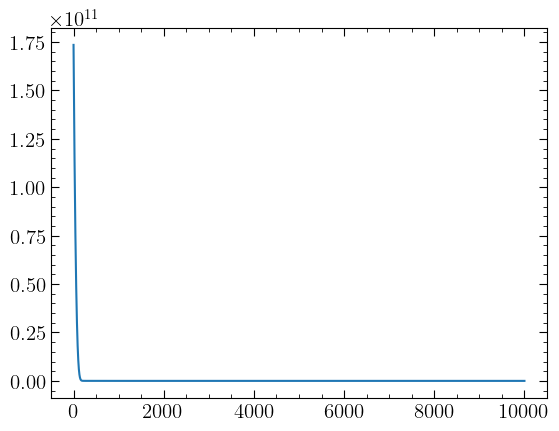

In [14]:
plt.plot(svi_results.losses[-1000000:])
plt.show()

# 3. Plot training data: pred vs. true

In [15]:
predict_train_values = model.predict_outputs(opt_pars["latents"], opt_pars)


fixed_pars = {
    "label": {"data": {"A": opt_pars["label"]["data"]["A"]}},
    "flux": {"data": {"A": opt_pars["flux"]["data"]["A"]}},
}


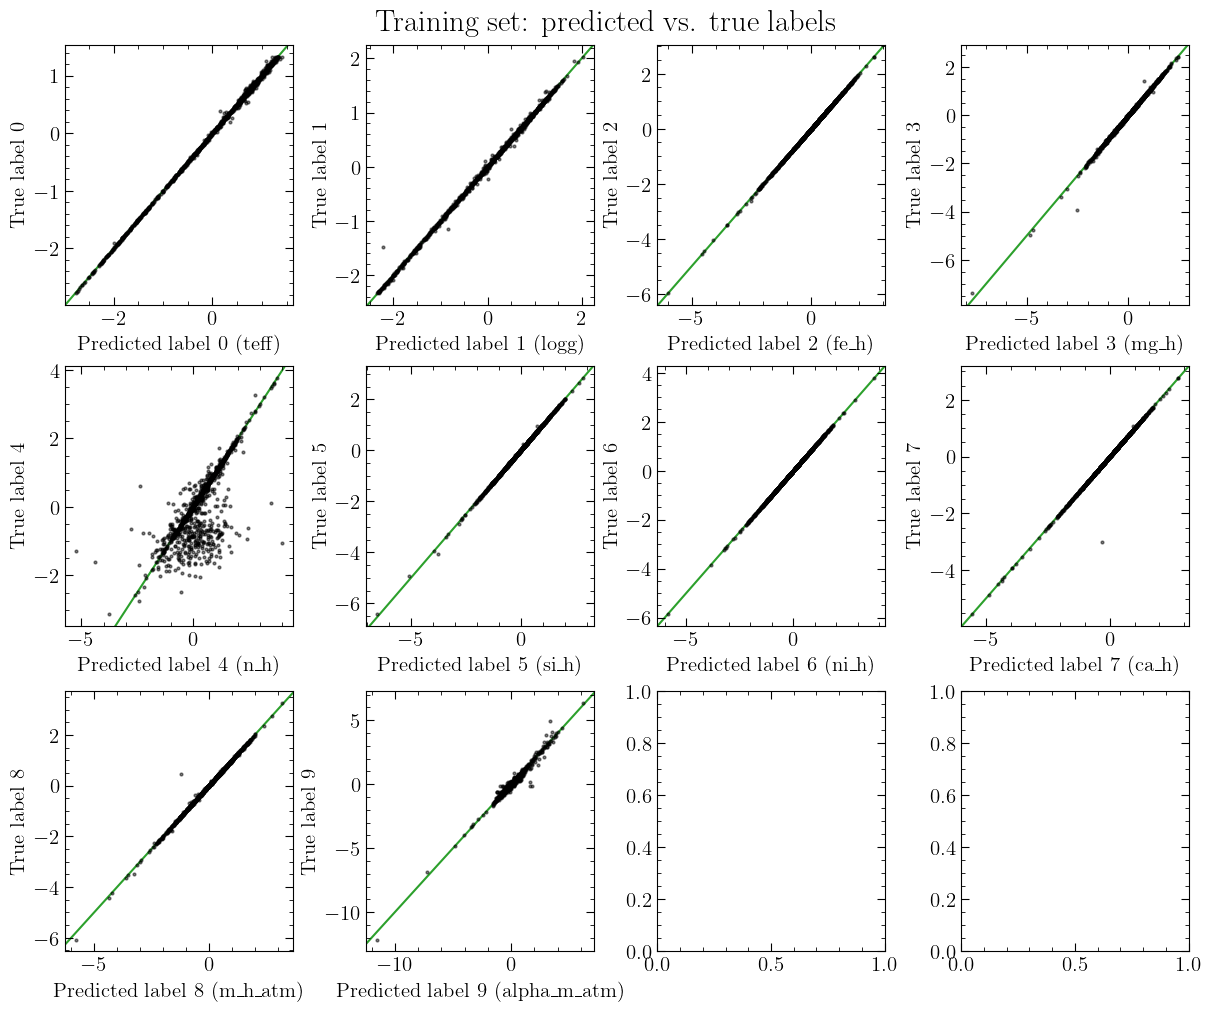

In [16]:
pt_style = {"ls": "none", "ms": 2.0, "alpha": 0.5, "marker": "o", "color": "k"}

fig, axes = plt.subplots(3, 4, figsize=(12, 10), layout="constrained")
axes = axes.flatten()
for i in range(predict_train_values["label"].shape[1]):
    axes[i].plot(
        predict_train_values["label"][:, i], train_data["label"].data[:, i], **pt_style
    )
    axes[i].set(xlabel=f"Predicted label {i} ({labels[i]})", ylabel=f"True label {i}")
    axes[i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
_ = fig.suptitle("Training set: predicted vs. true labels", fontsize=22)

plt.show()

In [17]:
# processing for all gaia rvs
all_fluxes_with_ca_mask = []
all_flux_errs_with_ca_mask = []


for i in range(len(df_gaia_rvs['flux'])):
	all_flux_single,all_flux_err_single = process_spectra(lambdas,df_gaia_rvs['flux'].iloc[i],df_gaia_rvs['flux_error'].iloc[i])

	all_fluxes_with_ca_mask.append(all_flux_single)
	all_flux_errs_with_ca_mask.append(all_flux_err_single)
	

all_flux_dict = {
    'flux': all_fluxes_with_ca_mask,
    'flux_err': all_flux_errs_with_ca_mask
}


all_flux_dict['flux'] = np.vstack([f.filled(1) if isinstance(f, np.ma.MaskedArray) else f
                              for f in all_flux_dict['flux']])

# Convert flux_err list to 2D array
all_flux_dict['flux_err'] = np.vstack([f.filled(9999) if isinstance(f, np.ma.MaskedArray) else f
                                  for f in all_flux_dict['flux_err']])

all_flux_data = plx.data.PolluxData(
    flux=plx.data.OutputData(
        all_flux_dict["flux"],
        err=all_flux_dict["flux_err"],
        # Reuse the exact preprocessor from your training set
        preprocessor=all_data["flux"].preprocessor, 
    )
)

preprocessed_all_flux_data = all_flux_data.preprocess()

# 4. Plot test data: pred vs. true

In [18]:
test_flux_only = plx.data.PolluxData(flux=test_data["flux"])

test_opt_pars_flux, _ = model.optimize(
    test_flux_only,
    rng_key=jax.random.PRNGKey(12345),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=10_000,
    fixed_pars=fixed_pars,
    names=["flux"],
    svi_run_kwargs={"progress_bar": False},
)

predict_test_values_flux = model.predict_outputs(
    test_opt_pars_flux["latents"], fixed_pars
)

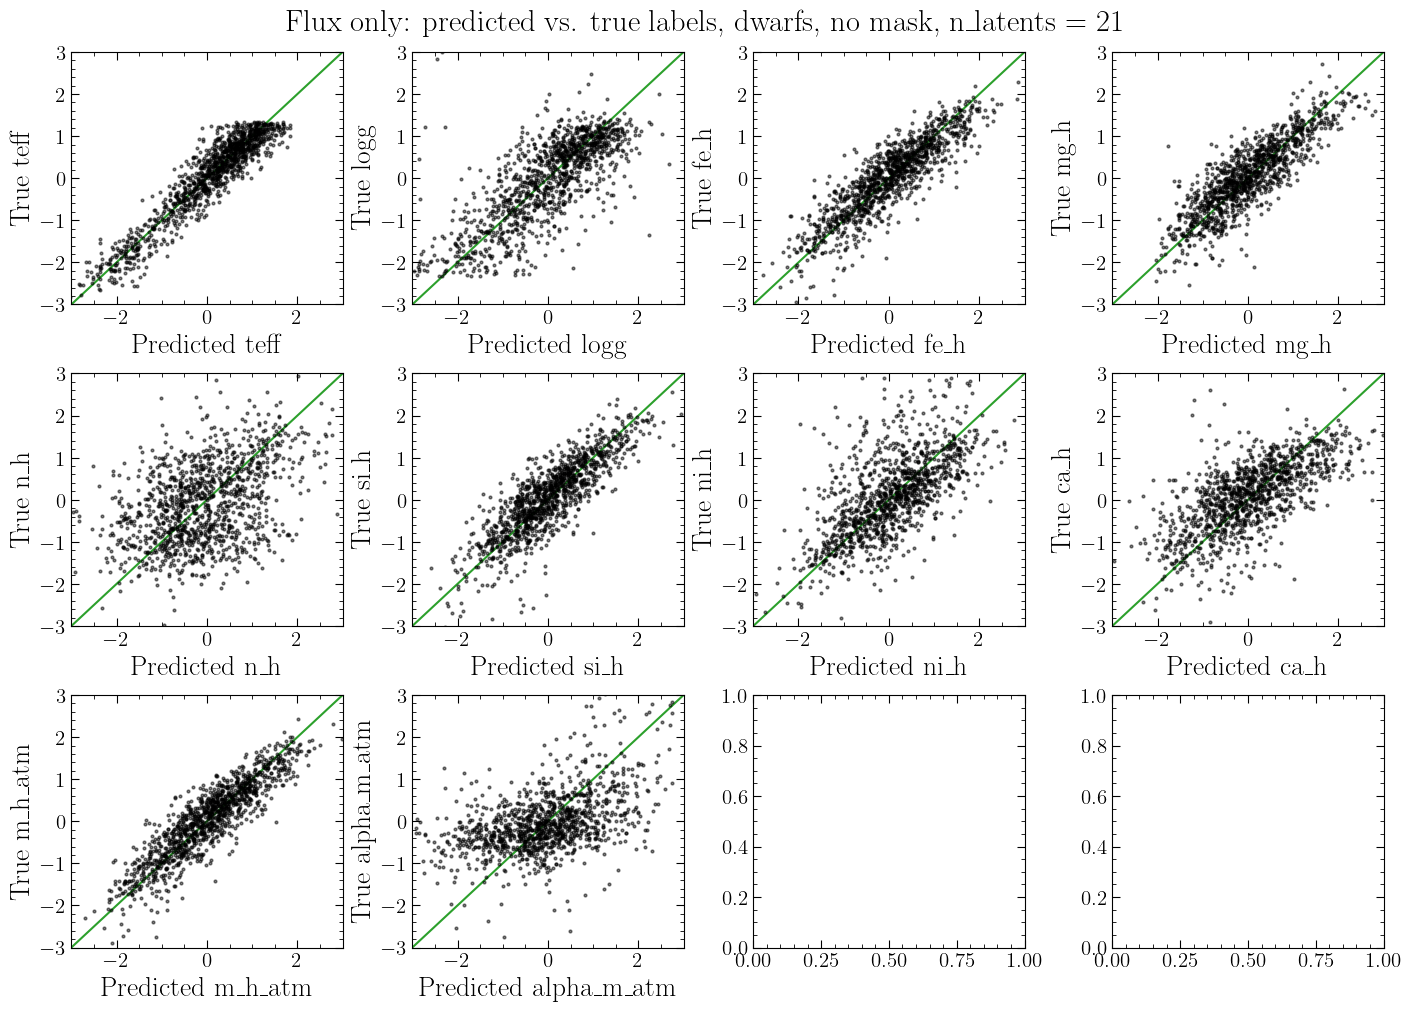

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10), layout="constrained")
axes = axes.flatten()
for i in range(predict_test_values_flux["label"].shape[1]):
    axes[i].plot(
        predict_test_values_flux["label"][:, i], test_data["label"].data[:, i], **pt_style
    )
    axes[i].set_xlabel(f"Predicted {labels[i]}", fontsize=20)
    axes[i].set_ylabel(f"True {labels[i]}", fontsize=20)
    axes[i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-3, 3)
_ = fig.suptitle(f"Flux only: predicted vs. true labels, dwarfs, no mask, n_latents = {n_latents}", fontsize=22)

plt.show()

In [20]:
predict_test_unprocessed = test_data.unprocess(predict_test_values_flux)
test_data_unprocessed = all_data[n_stars // 2:]

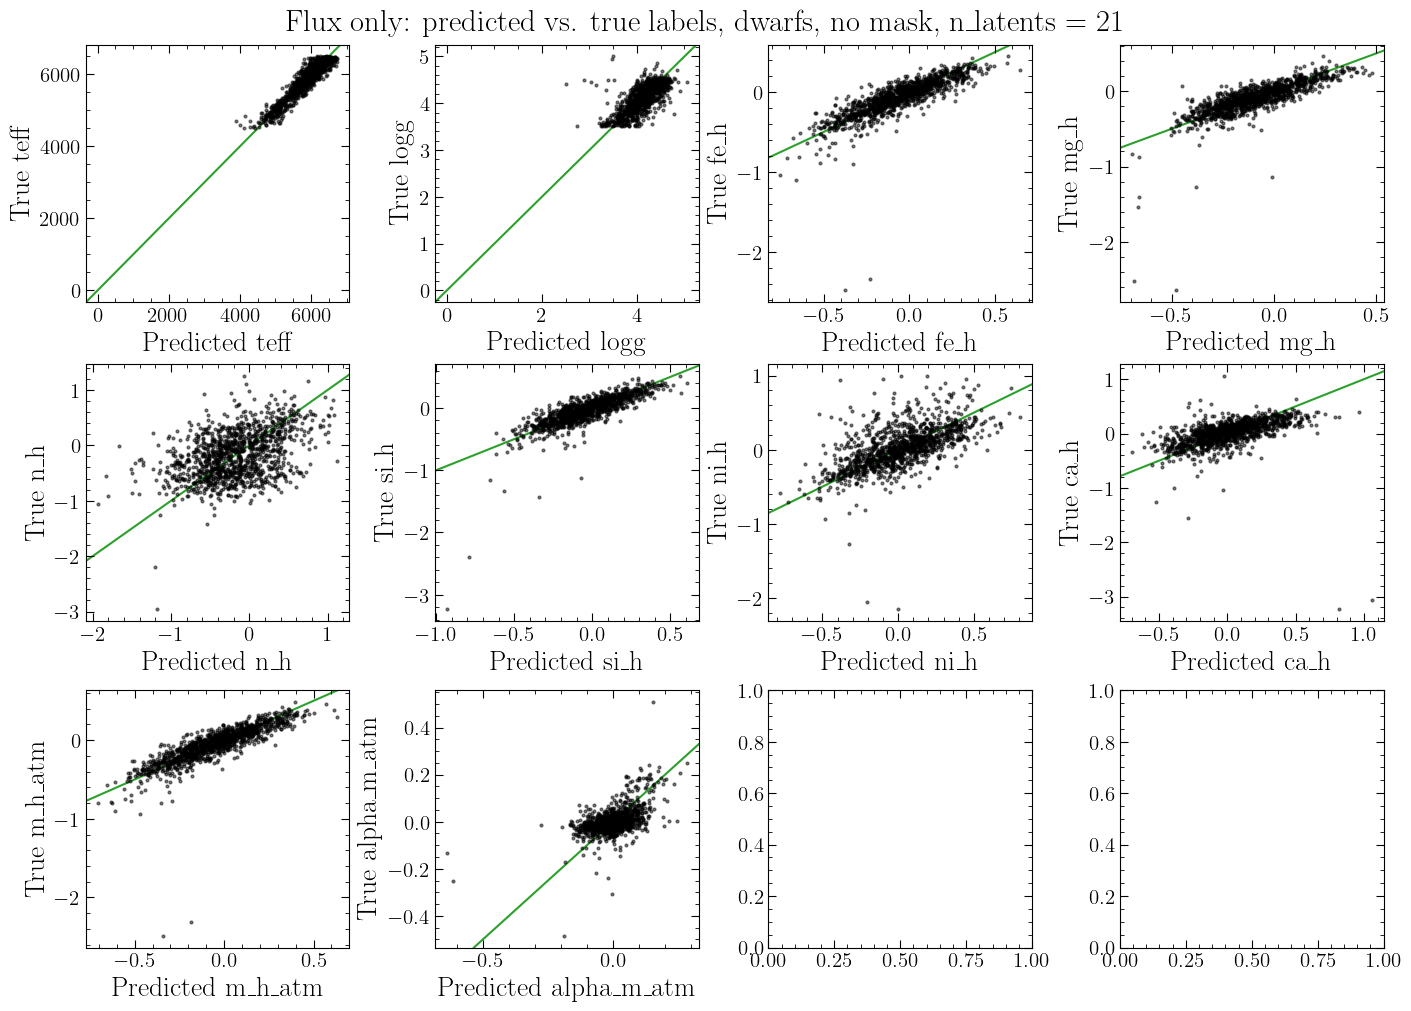

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10), layout="constrained")
axes = axes.flatten()
for i in range(predict_test_values_flux["label"].shape[1]):
    axes[i].plot(
        predict_test_unprocessed["label"].data[:, i], test_data_unprocessed["label"].data[:, i], **pt_style
    )
    axes[i].set_xlabel(f"Predicted {labels[i]}", fontsize=20)
    axes[i].set_ylabel(f"True {labels[i]}", fontsize=20)
    axes[i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
_ = fig.suptitle(f"Flux only: predicted vs. true labels, dwarfs, no mask, n_latents = {n_latents}", fontsize=22)

plt.show()

In [22]:
results = {}

for i, name in enumerate(labels):
    y_true = test_data_unprocessed["label"].data[:, i]
    y_pred = predict_test_unprocessed["label"].data[:, i]

    res = y_pred - y_true

    results[name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "residuals": res,
        "std_res": np.std(res),
        "RMSE": np.sqrt(np.mean(res**2)),
        "MAE": np.mean(np.abs(res)),
        "Bias": np.mean(res),
        "R2": 1 - np.sum(res**2) / np.sum((y_true - np.mean(y_true))**2),
    }


In [23]:
split_index = n_stars // 2
test_source_ids = df_stars['source_id'].iloc[split_index:].values

results = {}
df_dict = {}

# 2. Add the source_ids to your dictionary before the loop
df_dict["source_id"] = test_source_ids

for i, name in enumerate(labels):
    y_true = test_data_unprocessed["label"].data[:, i]
    y_pred = predict_test_unprocessed["label"].data[:, i]

    res = y_pred - y_true

    results[name] = {
        "std_res": np.std(res),
        "RMSE": np.sqrt(np.mean(res**2)),
        "MAE": np.mean(np.abs(res)),
        "Bias": np.mean(res),
        "R2": 1 - np.sum(res**2) / np.sum((y_true - np.mean(y_true))**2),
    }

    df_dict[f"{name}_true"] = y_true
    df_dict[f"{name}_pred"] = y_pred
    df_dict[f"{name}_residual"] = res

per_star_df = pd.DataFrame(df_dict)

In [24]:
per_star_df

,source_id,teff_true,teff_pred,teff_residual,logg_true,logg_pred,logg_residual,fe_h_true,fe_h_pred,fe_h_residual,...,ni_h_residual,ca_h_true,ca_h_pred,ca_h_residual,m_h_atm_true,m_h_atm_pred,m_h_atm_residual,alpha_m_atm_true,alpha_m_atm_pred,alpha_m_atm_residual
0,4418936033737014400,6150.602051,5929.069727,-221.532324,4.368,3.954108,-0.413892,-0.229,-0.370667,-0.141667,...,0.207774,-0.221,-0.139402,0.081598,-0.235,-0.333768,-0.098768,0.010,0.096297,0.086297
1,4421514319785782016,4960.304199,5073.751991,113.447792,3.529,3.562911,0.033911,-0.264,-0.190974,0.073026,...,0.202296,-0.198,-0.090060,0.107940,-0.254,-0.158711,0.095289,0.057,0.051647,-0.005353
2,4421707662032344192,4855.957031,4730.726433,-125.230598,4.395,4.215021,-0.179978,-0.058,-0.111492,-0.053492,...,-0.238426,-0.008,-0.038335,-0.030335,-0.055,-0.112596,-0.057596,0.009,-0.047489,-0.056489
3,4421722539799080832,6374.863770,6368.800111,-6.063659,4.205,4.085626,-0.119374,-0.143,-0.301054,-0.158054,...,-0.016938,-0.099,-0.311243,-0.212243,-0.149,-0.225763,-0.076763,-0.032,-0.028385,0.003615
4,4421857607930458624,6380.877930,6233.320680,-147.557250,4.169,3.952158,-0.216842,0.254,0.281128,0.027128,...,0.120507,0.237,0.283892,0.046892,0.257,0.314034,0.057034,-0.045,-0.053678,-0.008678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191,6914333056578041472,5885.679199,5985.658554,99.979355,4.134,4.203135,0.069135,-0.097,-0.049199,0.047801,...,0.076808,0.002,-0.131170,-0.133170,-0.104,-0.077626,0.026374,-0.020,-0.000401,0.019599
1192,6914596909304918400,6051.797852,5879.449007,-172.348845,4.134,3.861739,-0.272261,0.048,-0.054267,-0.102267,...,-0.139467,0.038,-0.007089,-0.045089,0.052,-0.032586,-0.084586,-0.018,0.038076,0.056076
1193,6914655316563957248,6039.414062,6061.825690,22.411627,4.158,4.318102,0.160102,-0.375,-0.512671,-0.137671,...,-0.037893,-0.296,-0.384684,-0.088684,-0.372,-0.487617,-0.115617,0.046,0.078512,0.032512
1194,6915081995795905920,6002.987793,5826.192957,-176.794836,3.780,3.607391,-0.172609,-0.060,-0.050987,0.009013,...,0.073535,-0.030,0.313523,0.343523,-0.067,-0.115524,-0.048524,-0.008,-0.021412,-0.013412


In [28]:
# save test results

per_star_df.to_csv("data/test_results_dwarfs.csv",  index=False)

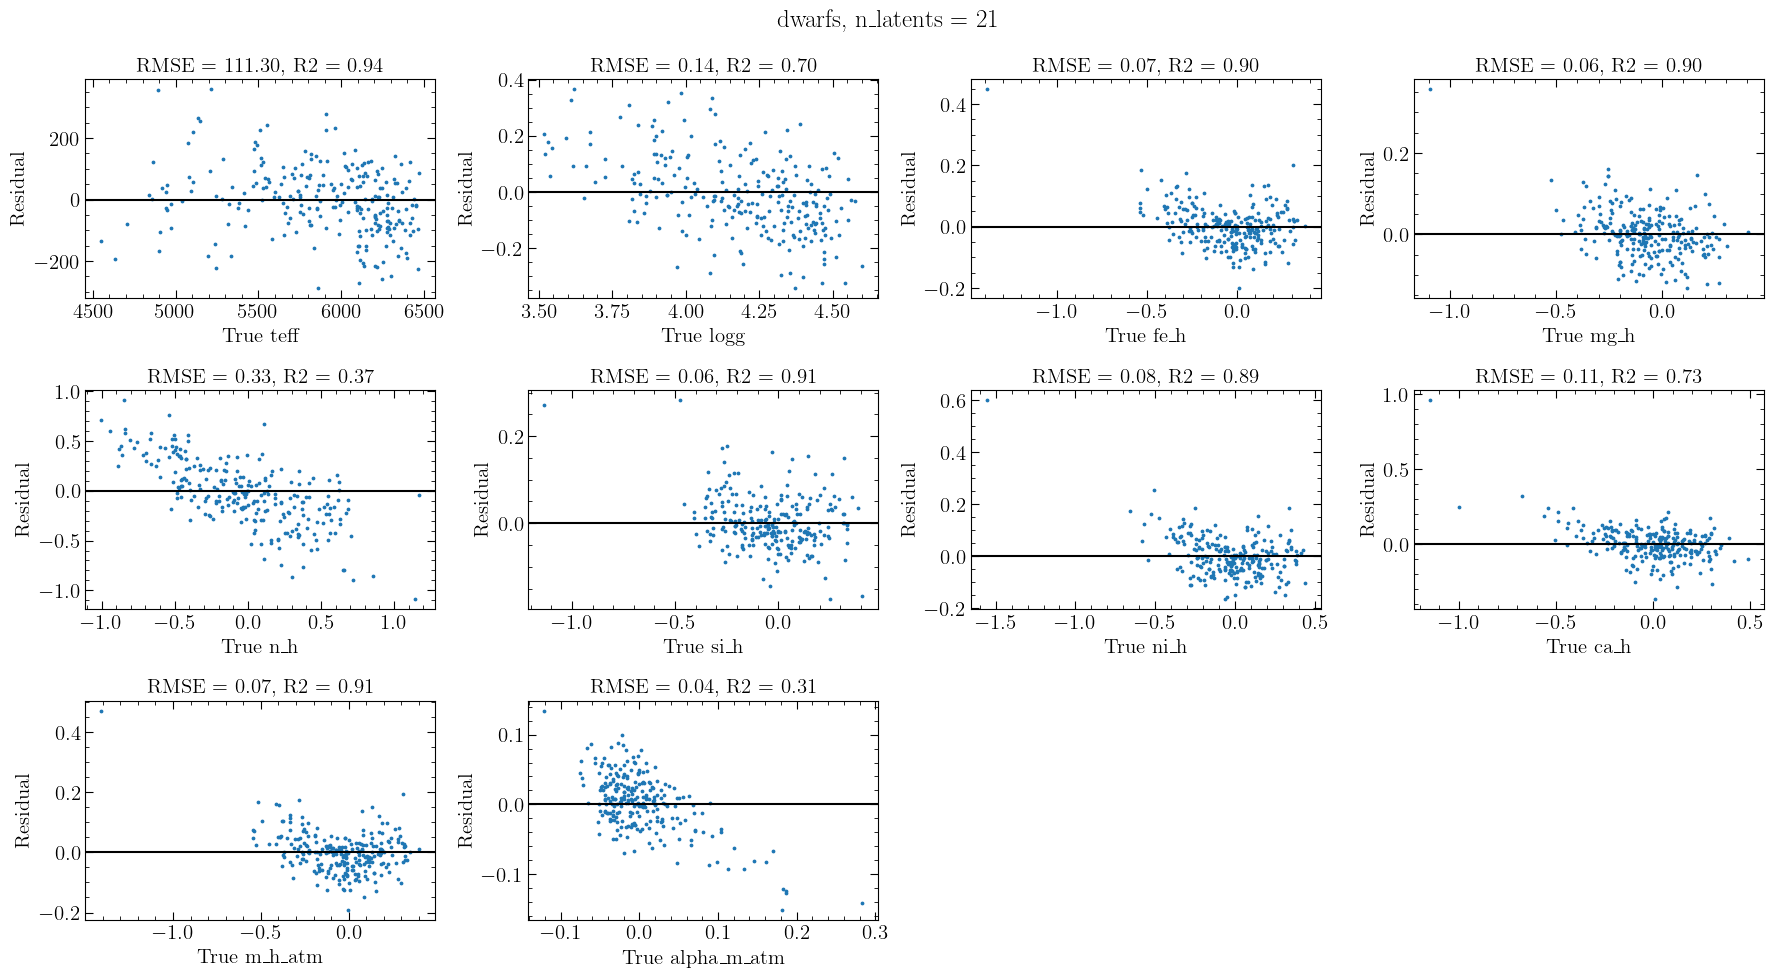

In [21]:
plt.figure(figsize=(18,10))

for i in range(len(labels)):
    name = labels[i]
    plt.subplot(3,4,i+1)
    plt.scatter(results[name]["y_true"], results[name]["residuals"], s = 3)
    plt.axhline(0, color="k")
    plt.xlabel(f"True {name}")
    plt.ylabel("Residual")
    plt.title(f"RMSE = {results[name]["RMSE"]:.2f}, R2 = {results[name]["R2"]:.2f}")

plt.suptitle(f"dwarfs, n_latents = {n_latents}")
plt.tight_layout()

# 5. Predict labels for non-labeled dataset (all Gaia stars)

In [33]:
# FIX: Use preprocessed_all_flux_data, not all_flux_data
flux_only_data = plx.data.PolluxData(flux=preprocessed_all_flux_data["flux"])

opt_pars_all_data, _ = model.optimize(
    flux_only_data,
    rng_key=jax.random.PRNGKey(12345),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=10_000,
    fixed_pars=fixed_pars,
    names=["flux"],
    svi_run_kwargs={"progress_bar": False},
)

predict_all_values_flux = model.predict_outputs(
    opt_pars_all_data["latents"], opt_pars
)


predict_all_unprocessed_flux = all_data.unprocess(predict_all_values_flux)

In [34]:
pred_data = predict_all_unprocessed_flux["label"].data[:]

data_to_save = pred_data[:, :len(labels)]

df_output = pd.DataFrame(data_to_save, columns=labels)

df_output['source_id'] = df_gaia_rvs['source_id']

#df_output.to_csv("data/dwarfs_predicted_mask_all_but_Fe_test.csv", index=False)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_33878/2651777107.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, '[Fe/Mg]')

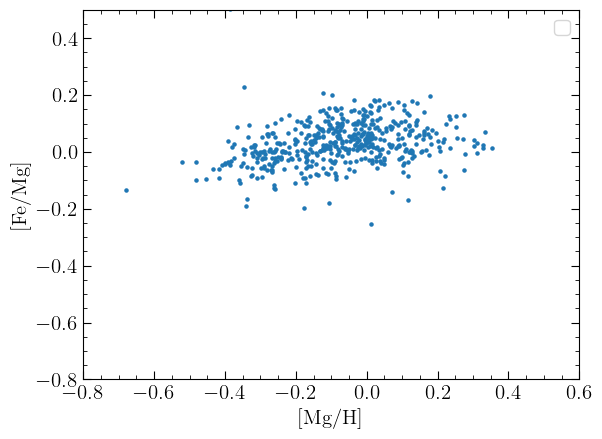

In [35]:
df_output['fe_mg'] = df_output['fe_h'] - df_output['mg_h']
 
plt.scatter(df_output['mg_h'], df_output['fe_mg'], s = 5)

plt.legend()
plt.ylim(-0.8,0.5)
plt.xlim(-0.8,0.6)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')